# Agentic Multi-Hop RAG — Analysis Notebook

**Dataset:** HotpotQA (distractor setting, validation split)  
**Samples:** 50  
**LLM:** Llama 3.1 8B Instruct  

This notebook loads the experiment results and produces comparison charts between the static baseline RAG and the iterative agentic RAG system.

In [1]:
# Cell 1: Load results
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

with open("../results/experiment_results.json") as f:
    results = json.load(f)

baseline = results["baseline"]
agentic  = results["agentic"]

df = pd.DataFrame(
    [baseline, agentic],
    index=["Baseline RAG", "Agentic RAG"]
)

print(df.to_string())

                EM        F1       MRR   NDCG@10  avg_hops  per_hop_MRR  per_hop_NDCG@10
Baseline RAG  0.00  0.074826  0.313667  0.387997      1.00          NaN              NaN
Agentic RAG   0.12  0.251838  0.338810  0.435223      3.72     0.339361         0.420107


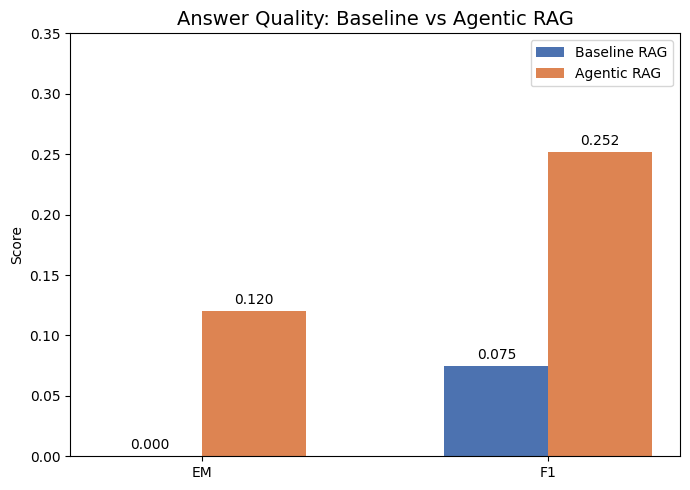

Saved: results/answer_quality_comparison.png


In [2]:
# Cell 2: Bar chart — answer quality metrics (EM and F1)
metrics_answer = ["EM", "F1"]
labels = ["Baseline RAG", "Agentic RAG"]
x = np.arange(len(metrics_answer))
width = 0.30

fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(x - width/2, [baseline[m] for m in metrics_answer], width, label="Baseline RAG", color="#4C72B0")
bars2 = ax.bar(x + width/2, [agentic[m]  for m in metrics_answer], width, label="Agentic RAG",  color="#DD8452")

ax.set_title("Answer Quality: Baseline vs Agentic RAG", fontsize=14)
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(metrics_answer)
ax.set_ylim(0, 0.35)
ax.legend()
ax.bar_label(bars1, fmt="%.3f", padding=3)
ax.bar_label(bars2, fmt="%.3f", padding=3)
plt.tight_layout()
plt.savefig("../results/answer_quality_comparison.png", dpi=150)
plt.show()
print("Saved: results/answer_quality_comparison.png")

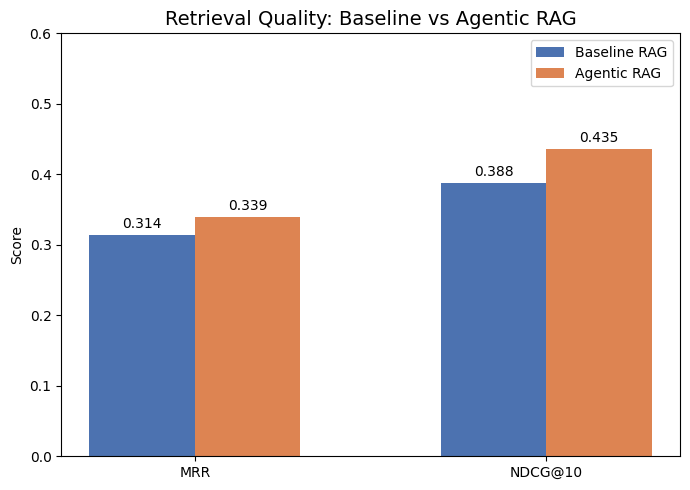

Saved: results/retrieval_quality_comparison.png


In [3]:
# Cell 3: Bar chart — retrieval quality metrics (MRR and NDCG@10)
metrics_ret = ["MRR", "NDCG@10"]
x = np.arange(len(metrics_ret))

fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(x - width/2, [baseline[m] for m in metrics_ret], width, label="Baseline RAG", color="#4C72B0")
bars2 = ax.bar(x + width/2, [agentic[m]  for m in metrics_ret], width, label="Agentic RAG",  color="#DD8452")

ax.set_title("Retrieval Quality: Baseline vs Agentic RAG", fontsize=14)
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(metrics_ret)
ax.set_ylim(0, 0.6)
ax.legend()
ax.bar_label(bars1, fmt="%.3f", padding=3)
ax.bar_label(bars2, fmt="%.3f", padding=3)
plt.tight_layout()
plt.savefig("../results/retrieval_quality_comparison.png", dpi=150)
plt.show()
print("Saved: results/retrieval_quality_comparison.png")

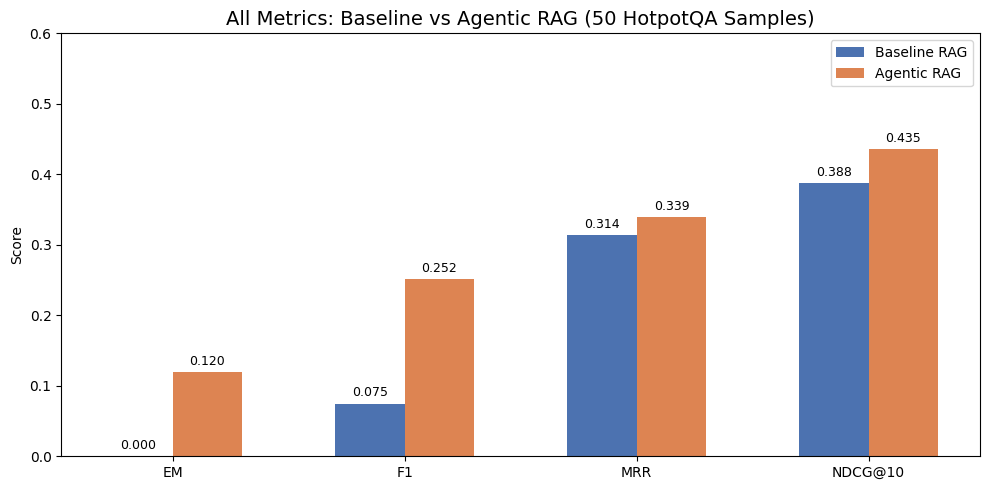

Saved: results/metrics_comparison.png


In [4]:
# Cell 4: All metrics side-by-side overview
metrics_all = ["EM", "F1", "MRR", "NDCG@10"]
x = np.arange(len(metrics_all))

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, [baseline[m] for m in metrics_all], width, label="Baseline RAG", color="#4C72B0")
bars2 = ax.bar(x + width/2, [agentic[m]  for m in metrics_all], width, label="Agentic RAG",  color="#DD8452")

ax.set_title("All Metrics: Baseline vs Agentic RAG (50 HotpotQA Samples)", fontsize=14)
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(metrics_all)
ax.set_ylim(0, 0.6)
ax.legend()
ax.bar_label(bars1, fmt="%.3f", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="%.3f", padding=3, fontsize=9)
plt.tight_layout()
plt.savefig("../results/metrics_comparison.png", dpi=150)
plt.show()
print("Saved: results/metrics_comparison.png")

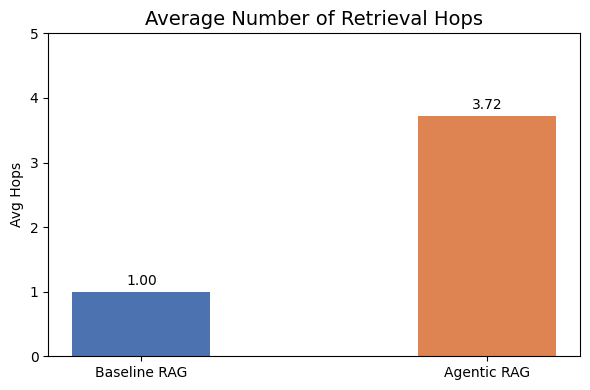

Saved: results/hop_count_comparison.png


In [5]:
# Cell 5: Hop count analysis
fig, ax = plt.subplots(figsize=(6, 4))
systems = ["Baseline RAG", "Agentic RAG"]
hops = [baseline["avg_hops"], agentic["avg_hops"]]
colors = ["#4C72B0", "#DD8452"]
bars = ax.bar(systems, hops, color=colors, width=0.4)
ax.set_title("Average Number of Retrieval Hops", fontsize=14)
ax.set_ylabel("Avg Hops")
ax.set_ylim(0, 5)
ax.bar_label(bars, fmt="%.2f", padding=3)
plt.tight_layout()
plt.savefig("../results/hop_count_comparison.png", dpi=150)
plt.show()
print("Saved: results/hop_count_comparison.png")

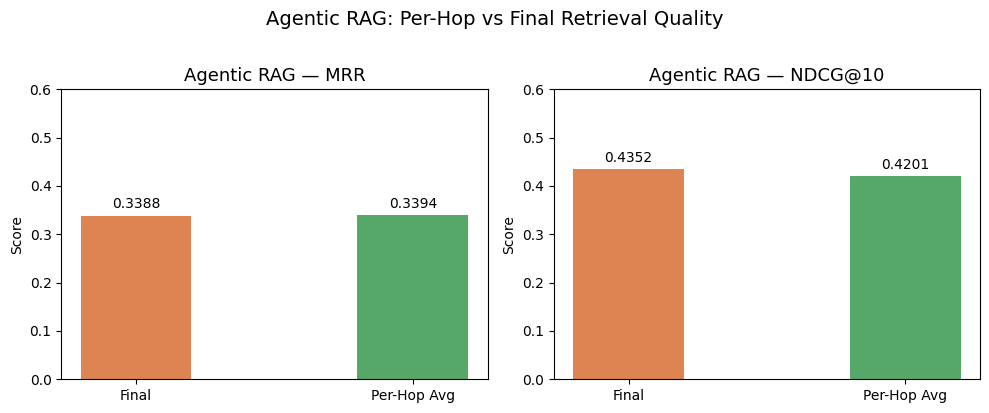

Saved: results/per_hop_vs_final.png


In [6]:
# Cell 6: Per-hop vs final retrieval metrics for the agentic system
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, metric, full_key, hop_key in zip(
    axes,
    ["MRR", "NDCG@10"],
    ["MRR", "NDCG@10"],
    ["per_hop_MRR", "per_hop_NDCG@10"],
):
    vals  = [agentic[full_key], agentic[hop_key]]
    bars_ = ax.bar(["Final", "Per-Hop Avg"], vals, color=["#DD8452", "#55a868"], width=0.4)
    ax.set_title(f"Agentic RAG — {metric}", fontsize=13)
    ax.set_ylim(0, 0.6)
    ax.set_ylabel("Score")
    ax.bar_label(bars_, fmt="%.4f", padding=3)

plt.suptitle("Agentic RAG: Per-Hop vs Final Retrieval Quality", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../results/per_hop_vs_final.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/per_hop_vs_final.png")

In [7]:
# Cell 7: Summary table
summary = pd.DataFrame({
    "Metric":        ["EM", "F1", "MRR", "NDCG@10", "Avg Hops"],
    "Baseline RAG":  [baseline["EM"], baseline["F1"], baseline["MRR"], baseline["NDCG@10"], baseline["avg_hops"]],
    "Agentic RAG":   [agentic["EM"],  agentic["F1"],  agentic["MRR"],  agentic["NDCG@10"],  agentic["avg_hops"]],
})
summary["Δ Absolute"] = summary["Agentic RAG"] - summary["Baseline RAG"]
summary["Δ %"] = ((summary["Agentic RAG"] - summary["Baseline RAG"]) / summary["Baseline RAG"].replace(0, float("nan")) * 100).round(1)
summary = summary.set_index("Metric")
print(summary.to_string(float_format="{:.4f}".format))

          Baseline RAG  Agentic RAG  Δ Absolute      Δ %
Metric                                                  
EM              0.0000       0.1200      0.1200      NaN
F1              0.0748       0.2518      0.1770 236.6000
MRR             0.3137       0.3388      0.0251   8.0000
NDCG@10         0.3880       0.4352      0.0472  12.2000
Avg Hops        1.0000       3.7200      2.7200 272.0000
